In [19]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [30]:
class CreditState(TypedDict):
    score : int
    result : str

In [31]:
def approved(state:CreditState)->CreditState:
    return {'result':f'your credit has been approved for your score: {state['score']}'}
def rejected(state:CreditState)->CreditState:
    return {'result':f'sorry! your credit has been rejected for your score: {state['score']}'}
def check(state)->Literal['approved','rejected']:
    if state['score'] > 650:
        return 'approved'
    else:
        return 'rejected'

In [32]:
graph = StateGraph(CreditState)
graph.add_node('approved',approved)
graph.add_node('rejected',rejected)

In [33]:
graph.add_conditional_edges(START,check)

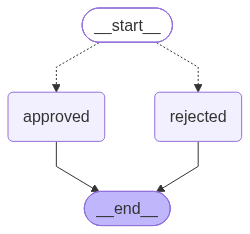

In [34]:
workflow = graph.compile()
workflow

In [35]:
initial_state = {
    'score':700
}
final_state = workflow.invoke(initial_state)
final_state

{'score': 700, 'result': 'your credit has been approved for your score: 700'}